## Librairies and functions

In [96]:
import sys
from pathlib import Path

for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

In [3]:
from model import Model
try:
    del model
except NameError:
    pass


c:\Users\loren\anaconda3\envs\cs_HeAims\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [97]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

In [98]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
    saved_data_folder = Path(species_folder) / "Saved_Data"
    if method_compression!=None:
        with open(Path(saved_data_folder, f"{species}_X_{dataset_type}_{method_compression}_{parameter_compression}.pkl"), "rb") as f:
            X = pickle.load(f)
    else : 
        print("load baseline")
        with open(Path(saved_data_folder, f"{species}_X_{dataset_type}.pkl"), "rb") as f:
            X = pickle.load(f)

    with open(Path(saved_data_folder, f"{species}_Y_{dataset_type}.pkl"), "rb") as f:
        Y = pickle.load(f)
    
    print(f"Dataset loaded from {saved_data_folder} for {dataset_type}")
    return X, Y

## Parameters

In [99]:
TARGET_SPECIES = "Gibbon"
settings = get_settings(TARGET_SPECIES.lower())
config = Config(settings)
print("Loaded settings for:", TARGET_SPECIES)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: PTW
{'sample_rate': 48000, 'lowpass_cutoff': 9000, 'downsample_rate': 18400, 'nyquist_rate': 9200, 'segment_duration': 2, 'nb_negative_class': 5, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 4000, 'f_max': 9000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': PosixPath('/home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'PTW', 'negative_class': 'NOISE'}


In [100]:
method_compression="encodec"
parameter_compression="6.0"

In [101]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

/home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/results/PTW_encodec_6.0


#### Architecture of the model

In [102]:
config.cnn_architecture.dict()

{'conv_layers': 1,
 'conv_filters': 8,
 'dropout_rate': 0.5,
 'conv_kernel': 8,
 'max_pooling_size': 4,
 'fc_units': 32,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None}

In [103]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64

In [104]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64


In [ ]:
#Gibbon : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 8
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=128

In [ ]:
#Bats
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 16
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=32

In [105]:
config.model.num_epochs=100

## Training

In [106]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for train
Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for val


In [107]:
print(f"Val set size: {len(X_val)}")
print(f"Train set size: {len(X_train)}")

Val set size: 4208
Train set size: 12523


In [108]:
from model import Model
try:
    del model
except NameError:
    pass
model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )



In [ ]:
model

In [109]:
"""
n_neg = 7084
n_pos = 2491

class_weights = [1.0, n_neg / n_pos]  # [1.0, 2.84]
"""

if method_compression!=None:
    model_name=method_compression+"_"+parameter_compression
else : 
    model_name="baseline"
train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)

Training:  12%|█▏        | 12/100 [01:25<10:28,  7.14s/epoch, lr=1.00e-03, train_loss=0.4275, val_loss=0.3826, best_val=0.3826]


KeyboardInterrupt: 

#### plot val and train loss

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot( val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
baseline_metric, baseline_metric_name = model.evaluate(
            X_val=X_val, Y_val=Y_val
        )
baseline_trainable_params = model.get_number_of_parameters()
print(baseline_metric)

## Evaluation of the model

In [ ]:
from evaluation import Evaluation
from model import Model
try:
    del model
except NameError:
    pass
import torch
import os

In [ ]:
TARGET_SPECIES = "Gibbon"
settings = get_settings(TARGET_SPECIES.lower())
config = Config(settings)
print("Loaded settings for:", TARGET_SPECIES)
print(config.preprocessing.dict())
print(config.data.dict())

In [ ]:
method_compression="encodec"
parameter_compression="6.0"

In [ ]:
from model import Model
try:
    del model
except NameError:
    pass
model_path = os.path.join(save_path, model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model.load_cnn(model_path, device)

In [ ]:
overlap=0.10
nb_to_group=0
threshold=0.8
step_size=1

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                step_size=step_size,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

In [ ]:
evaluation.run(model, type="val", test_type="testing_dataset")

In [ ]:
evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

## Calculation of the threshold 

In [ ]:
thresholds=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
Precision=[]
Recall=[]
overlap=0.10
nb_to_group=0
for threshold in thresholds : 


    print("Threshold : ", threshold)
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )
    _, matrice, _ , precision, recall= evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

    Precision.append(precision)
    Recall.append(recall)


    
    

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(np.asarray(thresholds), np.asarray(Precision), color='steelblue', lw=2, label='Precision')
ax.plot(np.asarray(thresholds), np.asarray(Recall), color='coral', lw=2, label='Recall')

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall vs Threshold', fontsize=13)
ax.set_xlim([min(thresholds), max(thresholds)])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Loop CNN training + evaluation

In [110]:
import torch
import os
from evaluation import Evaluation
from model import Model
try:
    del model
except NameError:
    pass
import shutil

In [111]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle
import pandas as pd
import gc


In [112]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
    saved_data_folder = Path(species_folder) / "Saved_Data"
    if method_compression!=None:
        with open(Path(saved_data_folder, f"{species}_X_{dataset_type}_{method_compression}_{parameter_compression}.pkl"), "rb") as f:
            X = pickle.load(f)
    else : 
        print("load baseline")
        with open(Path(saved_data_folder, f"{species}_X_{dataset_type}.pkl"), "rb") as f:
            X = pickle.load(f)

    with open(Path(saved_data_folder, f"{species}_Y_{dataset_type}.pkl"), "rb") as f:
        Y = pickle.load(f)
    
    print(f"Dataset loaded from {saved_data_folder} for {dataset_type}")
    return X, Y

#### Parameters

In [113]:
TARGET_SPECIES = "Gibbon"
settings = get_settings(TARGET_SPECIES.lower())
config = Config(settings)
print("Loaded settings for:", TARGET_SPECIES)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: PTW
{'sample_rate': 48000, 'lowpass_cutoff': 9000, 'downsample_rate': 18400, 'nyquist_rate': 9200, 'segment_duration': 2, 'nb_negative_class': 5, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 4000, 'f_max': 9000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': PosixPath('/home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'PTW', 'negative_class': 'NOISE'}


In [114]:
method_compression="encodec"
parameter_compression="6.0"

In [115]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

/home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/results/PTW_encodec_6.0


In [116]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for train
Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for val


In [117]:
overlap=0.10  #0.25 for ptw and gibbon 0.10 for thyolo
nb_to_group=0 #2 for ptw and gibbon 0 for thyolo
threshold=0.8

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

##### architecture

In [ ]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64

In [118]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64


##### Loop : 10 runs

0
Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for train
Dataset loaded from /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data for val
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 100, 'batch_size': 64, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  54%|█████▍    | 54/100 [06:20<05:23,  7.04s/epoch, lr=2.50e-04, train_loss=0.3716, val_loss=0.3748, best_val=0.3710]


Early stopping triggered at epoch 55


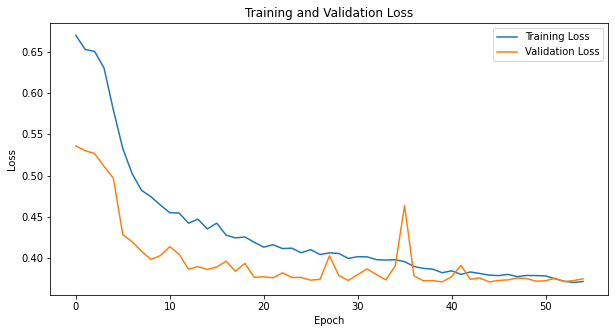

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8548470710212546
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2818
           1       0.84      0.87      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.88      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2514  304]
 [ 256 1649]]
creating the folder
Processing file: ['20210125_030030']
2026-07-07 20:30:51.1 Processing file: ['20210125_030030'] 
No amplitudes to predict found on disk
Found file
2026-07-07 20:30:51.1 Load 20210125_030030 data 
20210125_030030
Filtering...
Downsampling...
2026-07-07 20:30:57.7 Create list of spectrograms
Saved amplitudes to predict to disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predic

Training:  61%|██████    | 61/100 [07:07<04:33,  7.00s/epoch, lr=6.25e-05, train_loss=0.3645, val_loss=0.3713, best_val=0.3705]


Early stopping triggered at epoch 62


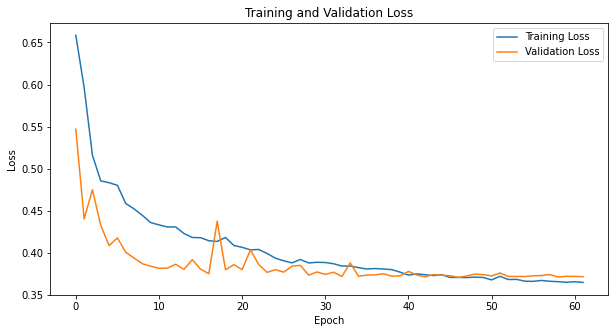

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8575129533678757
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2818
           1       0.85      0.87      0.86      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.88      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2518  300]
 [ 250 1655]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 20:51:24.2 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 20:51:24.6 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  48%|████▊     | 48/100 [05:36<06:04,  7.01s/epoch, lr=6.25e-05, train_loss=0.3694, val_loss=0.3812, best_val=0.3726]


Early stopping triggered at epoch 49


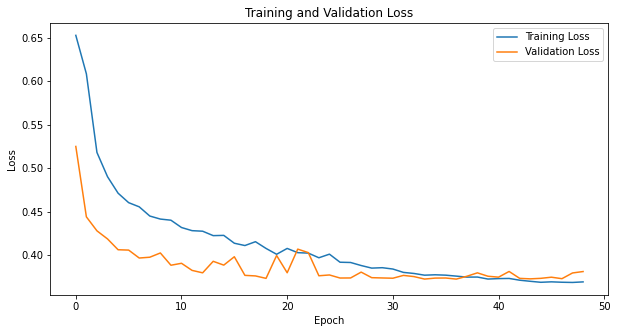

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8555844155844156
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2818
           1       0.85      0.86      0.86      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.88      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2520  298]
 [ 258 1647]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 20:58:07.6 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 20:58:08.0 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  45%|████▌     | 45/100 [05:16<06:26,  7.03s/epoch, lr=1.25e-04, train_loss=0.3762, val_loss=0.3768, best_val=0.3731]


Early stopping triggered at epoch 46


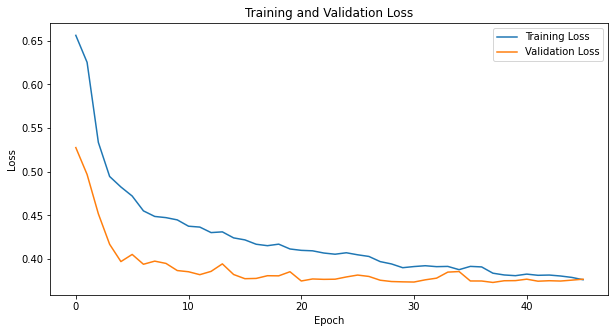

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8479408658922915
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2818
           1       0.85      0.84      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.87      0.87      0.87      4723
weighted avg       0.88      0.88      0.88      4723

[[2541  277]
 [ 299 1606]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:04:29.6 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:04:30.0 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  77%|███████▋  | 77/100 [08:56<02:40,  6.97s/epoch, lr=1.25e-04, train_loss=0.4001, val_loss=0.3799, best_val=0.3785]


Early stopping triggered at epoch 78


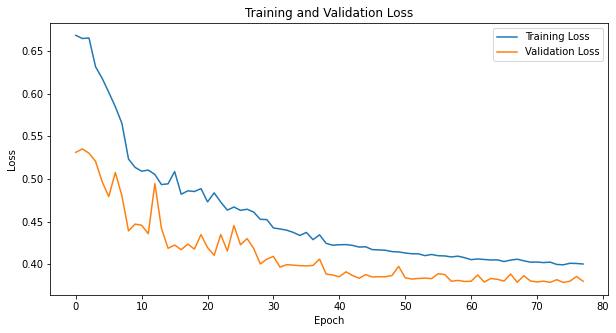

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.830249396621078
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      2818
           1       0.85      0.81      0.83      1905

    accuracy                           0.87      4723
   macro avg       0.86      0.86      0.86      4723
weighted avg       0.87      0.87      0.87      4723

[[2542  276]
 [ 357 1548]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:14:34.0 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:14:34.5 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensin

Training:  55%|█████▌    | 55/100 [06:25<05:15,  7.00s/epoch, lr=1.25e-04, train_loss=0.3691, val_loss=0.3778, best_val=0.3741]


Early stopping triggered at epoch 56


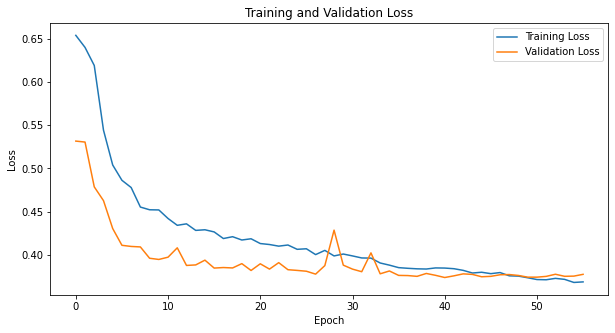

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8455070940620073
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2818
           1       0.85      0.84      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.87      0.87      0.87      4723
weighted avg       0.88      0.88      0.88      4723

[[2526  292]
 [ 296 1609]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:22:01.9 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:22:02.3 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  44%|████▍     | 44/100 [05:24<06:52,  7.37s/epoch, lr=2.50e-04, train_loss=0.3697, val_loss=0.3718, best_val=0.3715]


Early stopping triggered at epoch 45


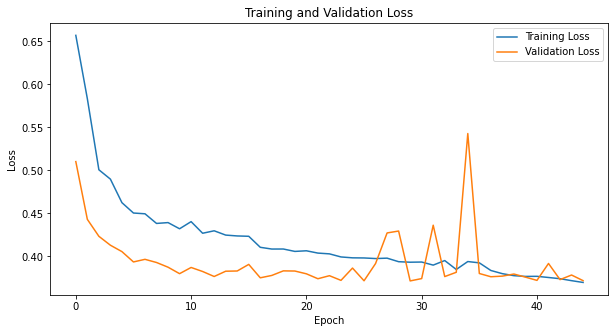

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8553686934023286
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2818
           1       0.84      0.87      0.86      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.88      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2511  307]
 [ 252 1653]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:28:38.8 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:28:39.2 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  42%|████▏     | 42/100 [04:58<06:51,  7.10s/epoch, lr=1.25e-04, train_loss=0.3744, val_loss=0.3756, best_val=0.3729]


Early stopping triggered at epoch 43


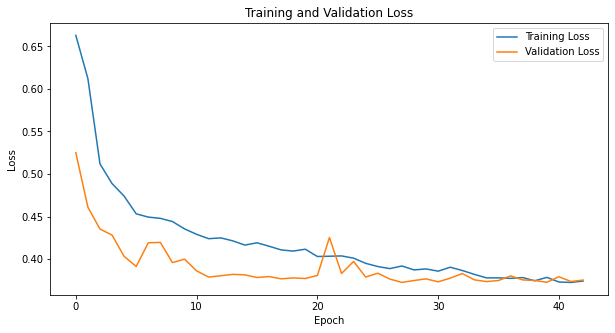

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8531505404692855
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2818
           1       0.86      0.85      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.88      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2548  270]
 [ 287 1618]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:34:45.2 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:34:45.8 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  56%|█████▌    | 56/100 [06:34<05:10,  7.05s/epoch, lr=6.25e-05, train_loss=0.3655, val_loss=0.3707, best_val=0.3707]


Early stopping triggered at epoch 57


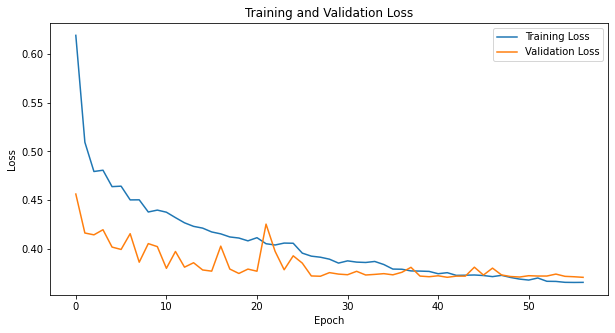

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8486274509803922
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      2818
           1       0.85      0.85      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.87      0.87      0.87      4723
weighted avg       0.88      0.88      0.88      4723

[[2521  297]
 [ 282 1623]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:43:23.8 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:43:24.2 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

Training:  40%|████      | 40/100 [04:41<07:02,  7.03s/epoch, lr=1.25e-04, train_loss=0.3749, val_loss=0.3740, best_val=0.3717]


Early stopping triggered at epoch 41


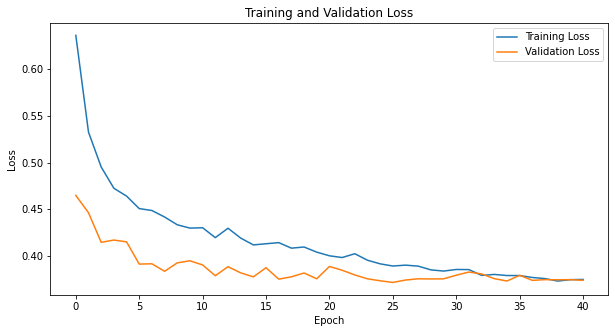

Data Loaded from:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/Saved_Data
Evaluating...
f1 score : 0.8508403361344538
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2818
           1       0.85      0.85      0.85      1905

    accuracy                           0.88      4723
   macro avg       0.88      0.87      0.88      4723
weighted avg       0.88      0.88      0.88      4723

[[2535  283]
 [ 285 1620]]
clean the folder
Processing file: ['20210125_030030']
2026-07-07 21:49:11.6 Processing file: ['20210125_030030'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensing_bioacoustics/Data/PTW/amplitudes_to_predict_.WAV/20210125_030030_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20210125_032035']
2026-07-07 21:49:12.1 Processing file: ['20210125_032035'] 
Found amplitudes to predict on disk:  /home/milanto/Documents/all-code/compressed_sensi

' \n#clean the folder with amplitudes \nif os.path.exists(evaluation.save_amplitudes_path):\n    shutil.rmtree(evaluation.save_amplitudes_path)\n    print(f"Folder \'{evaluation.save_amplitudes_path}\' and its contents deleted successfully.")\nelse:\n    print(f"Folder \'{evaluation.save_amplitudes_path}\' does not exist.")\n'

In [119]:
from model import Model
try:
    del model
except NameError:
    pass
first_loop=0
last_loop=10

F1_score_full=[]
F1_score=[]

for i in range(first_loop, last_loop): 
    
    
    #clean gpu
    torch.cuda.empty_cache()
    gc.collect()
    
    
    print(i)
    #create folder to save model 
    #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
    #os.makedirs(dir_out)
    X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
    X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
    #I- Training
    #initialise the model 
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )
    print(config.model.dict())

    

    #train
    if method_compression!= None : 
        model_name=method_compression+"_"+parameter_compression
    else : 
        model_name="baseline"
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)


    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot( val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig(Path(save_path, f"Training_and_Validation_Loss_{i}.png"))
    plt.show()
    


    # II- Evaluation
    #load the saved model
    if method_compression!= None :
        model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
    else : 
        model_name="baseline_cnn_state.pth"
    model_path = os.path.join(save_path, model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Model.load_cnn(model_path, device)

    f1_score=evaluation.run(model, test_type="testing_dataset")[0]
    f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

    F1_score.append(f1_score)
    F1_score_full.append(f1_score_full)

#save f1 score
df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full)))

""" 
#clean the folder with amplitudes 
if os.path.exists(evaluation.save_amplitudes_path):
    shutil.rmtree(evaluation.save_amplitudes_path)
    print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
else:
    print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
"""

#### Loop on hyperparameter + loop on 10 runs

In [ ]:
from model import Model
try:
    del model
except NameError:
    pass
overlap=0.10
nb_to_group=0
threshold=0.8
parameters_list=["1.5", "3.0", "6.0"]

for parameter_compression in parameters_list : 
    if method_compression!=None : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
        save_path.mkdir(parents=True, exist_ok=True)
    else : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
        save_path.mkdir(parents=True, exist_ok=True)
    print(save_path)

    
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

    first_loop=0
    last_loop=10

    F1_score_full=[]
    F1_score=[]

    for i in range(first_loop, last_loop): 
      
        #clean gpu
        torch.cuda.empty_cache()
        gc.collect()
        
        
        print(i)
        #create folder to save model 
        #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
        #os.makedirs(dir_out)
        X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
        X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
        
        #I- Training
        #initialise the model 
        model = Model(save_path,
                input_shape=(1, X_train.shape[1], X_train.shape[2]),
                architecture_args= config.cnn_architecture.dict(),
                **config.model.dict(),
            )

        #train
        if method_compression!= None : 
            model_name=method_compression+"_"+parameter_compression
        else : 
            model_name="baseline"
        train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=False)

        # II- Evaluation
        #load the saved model
        if method_compression!= None :
            model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
        else : 
            model_name="baseline_cnn_state.pth"
        model_path = os.path.join(save_path, model_name)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = Model.load_cnn(model_path, device)

        f1_score=evaluation.run(model, test_type="testing_dataset")[0]
        f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

        F1_score.append(f1_score)
        F1_score_full.append(f1_score_full)

    #save f1 score
    df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
    df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

    print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
    print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full))) 
    
    
    #clean the folder with amplitudes 
    if os.path.exists(evaluation.save_amplitudes_path):
        shutil.rmtree(evaluation.save_amplitudes_path)
        print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
    else:
        print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
    
    
    print("Next parameter")


        

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0
0
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW/train/PTW_X_train_flac_0
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW/val/PTW_X_val_flac_0
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Docum

KeyboardInterrupt: 